Manuela Ardila Pineda

# Punto 1. Describir lo que significan para el problema de negocio, cada una de las variables que hacen parte de la base de datos. Para esto es necesario leer el planteamiento del problema de negocio descrito en el libro guía.

### Monstermash, una empresa que se dedica al desarrollo de juegos en línea, ellos quieren predecir qué jugadores es probable que realicen compras dentro de la aplicación. Para esto, las variables que van a tener en cuenta son:    
- Age: Edad del cliente.   
- Sex: Sexo del cliente; si Sex = 1 es hombre y Sex = 0 es mujer.   
- Income: Ingreso del hogar en múltiplos de $1 000.   
- Years: Número de años jugando juegos en línea.   
- Hours: Número de horas de juego en línea por semana.   
- CreditCard: Si el cliente tiene una tarjeta de crédito; si CreditCard = 1 es sí y CreditCard = 0 es no.   
- Facebook: Si el cliente tiene un perfil en Facebook; si Facebook = 1 es sí y Facebook = 0 es no.   
- Buy: Si el cliente ha hecho anteriormente compras en la app; si Buy = 1 es sí y Buy = 0 es no.  .

# Desarrollo

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pandas as pd
solicitantes = pd.read_excel("/content/drive/MyDrive/Analítica de Negocios/RETO 3/3. In_App_Pur_Data.xlsx", sheet_name=0)

In [22]:
solicitantes.shape

(400, 8)

***NOTA:*** No hay que eliminar las celdas vacías de la base de datos, ya que la base de datos está completa y no contiene valores faltantes.

In [66]:
AAA = solicitantes

In [18]:
print(AAA.groupby('Buy').size())

Buy
0    189
1    211
dtype: int64


In [19]:
import seaborn as sns

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


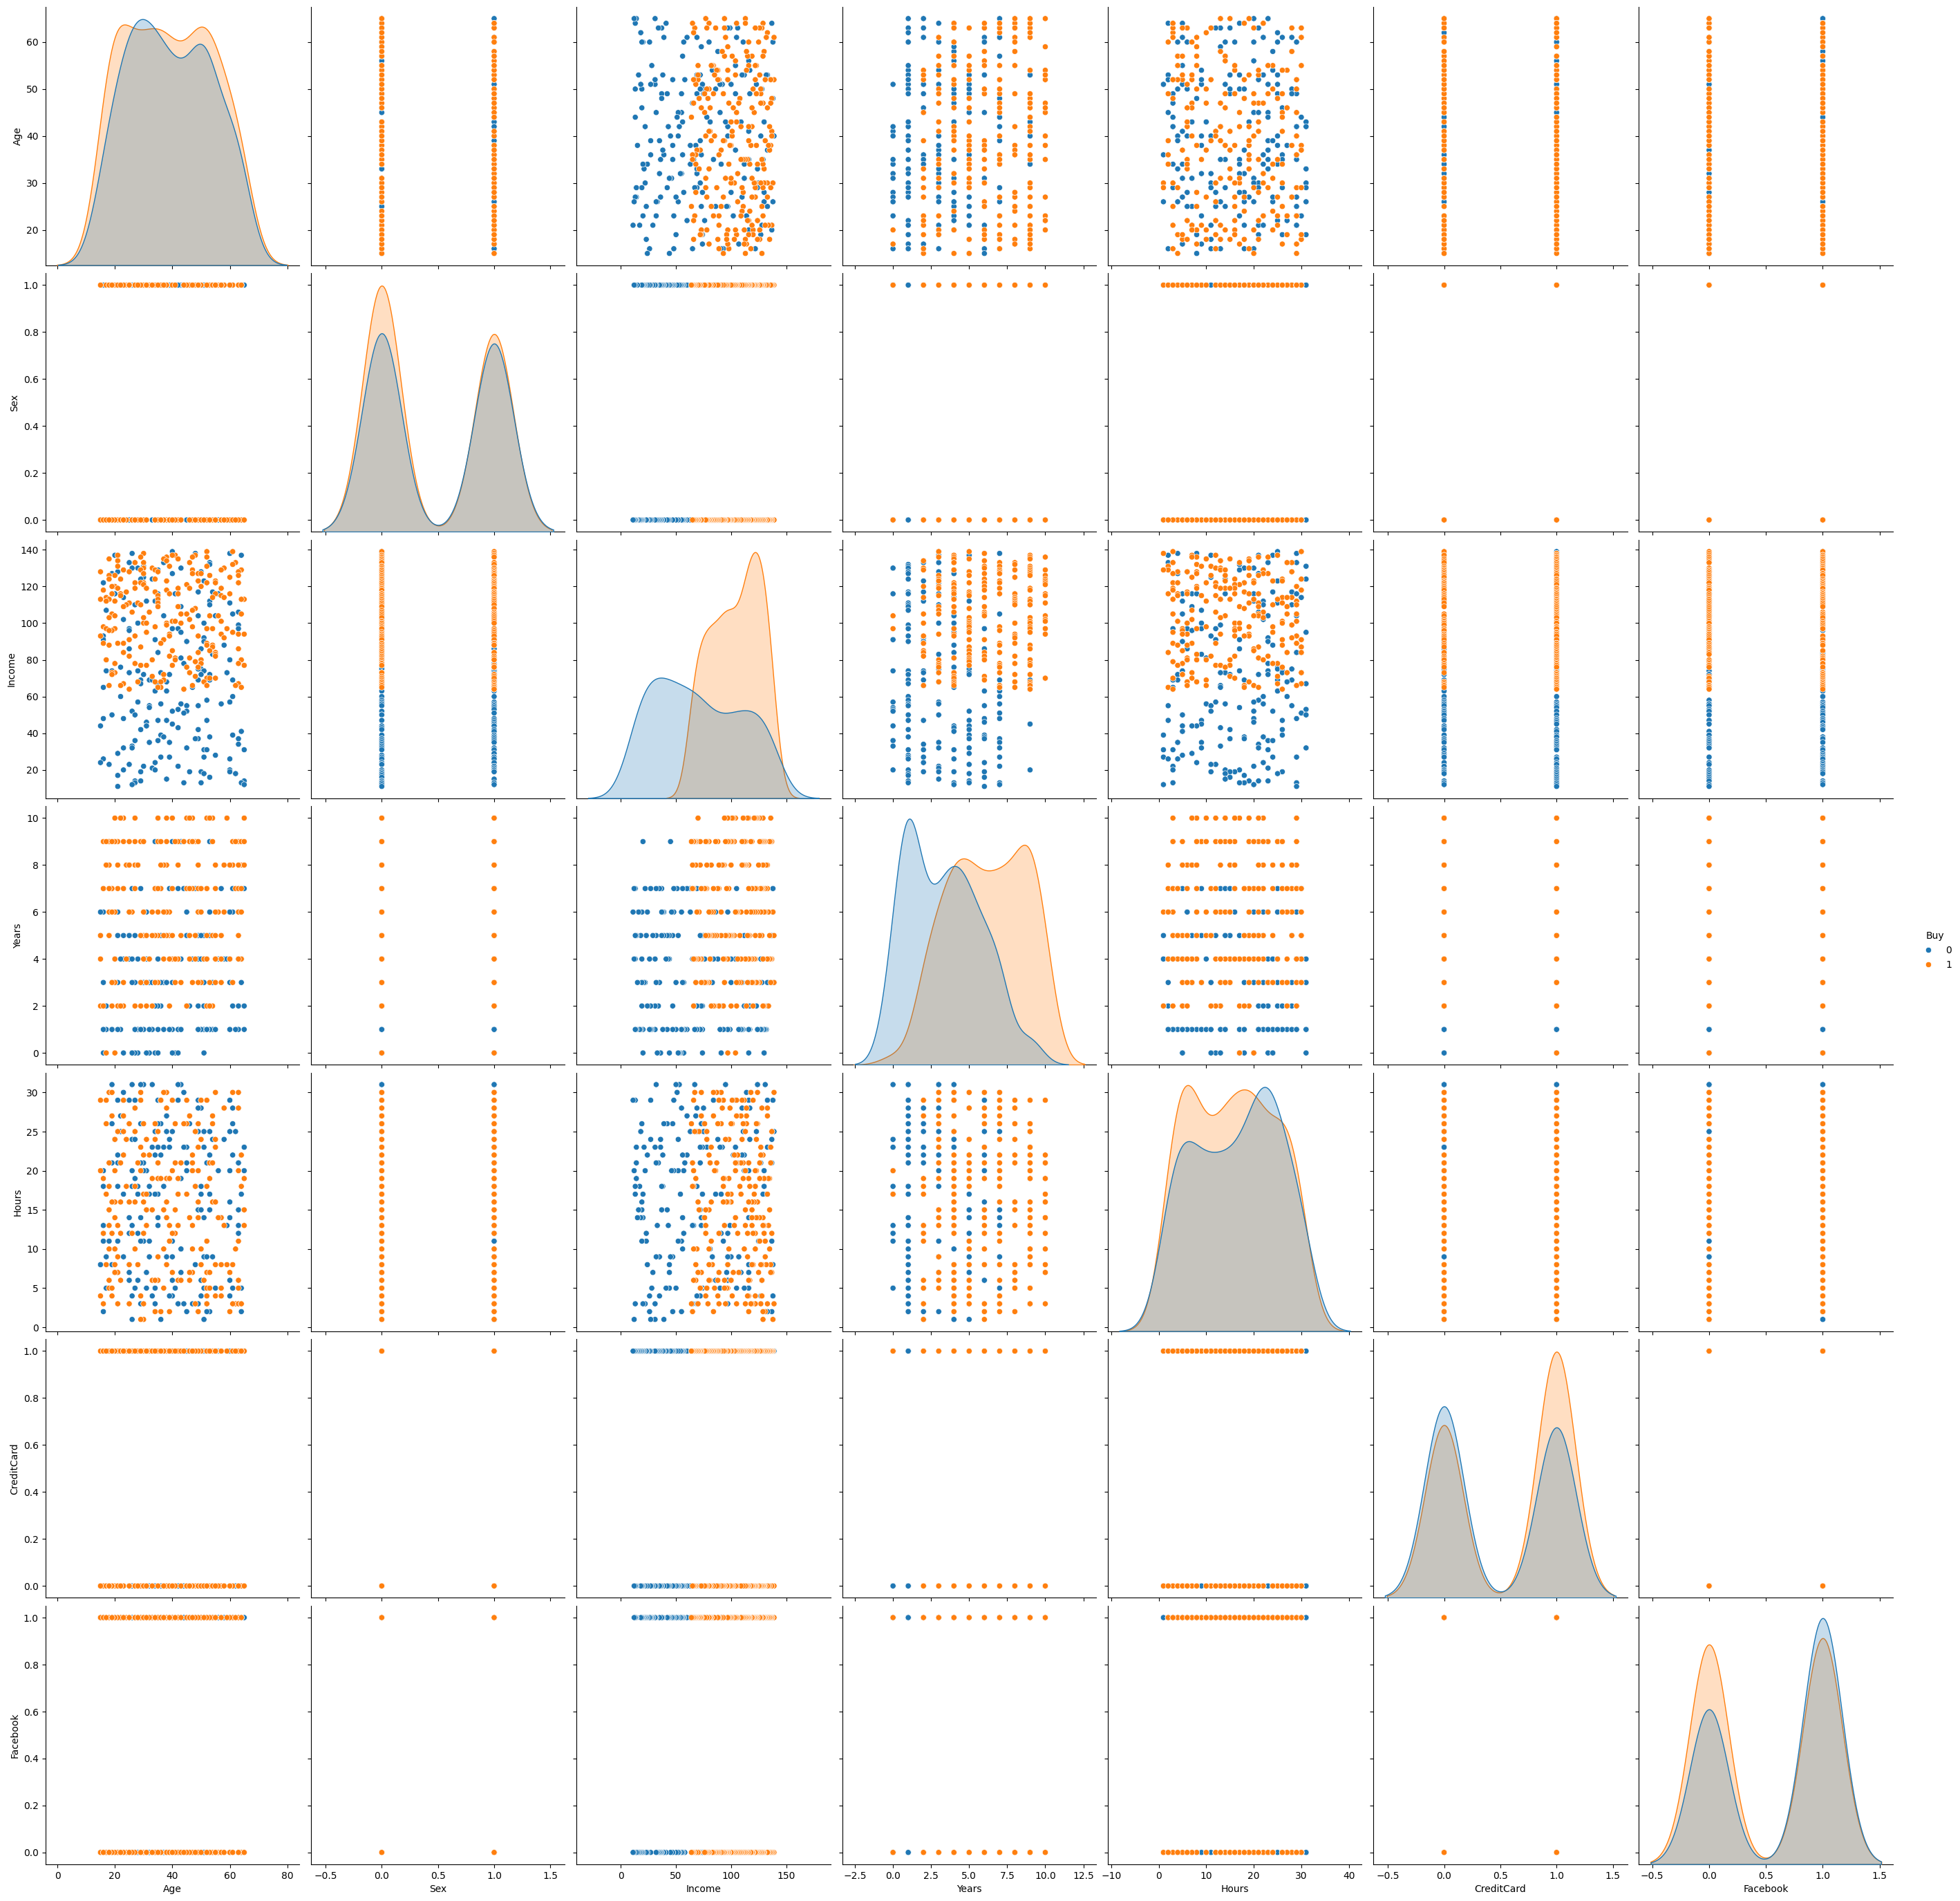

In [25]:
sns.pairplot(AAA, hue='Buy', size=4, vars=["Age", "Sex", "Income", "Years", "Hours", "CreditCard", "Facebook"])

In [27]:
XD = AAA[["Age", "Sex", "Income", "Years", "Hours", "CreditCard", "Facebook"]]

In [28]:
yd = solicitantes ["Buy"].dropna()

In [29]:
import numpy as np
dfinf = pd.DataFrame(np.column_stack((XD, yd)))
dfinf.columns = ["Age", "Sex", "Income", "Years", "Hours", "CreditCard", "Facebook", "Buy"]

mCorr = dfinf.corr()

<Axes: >

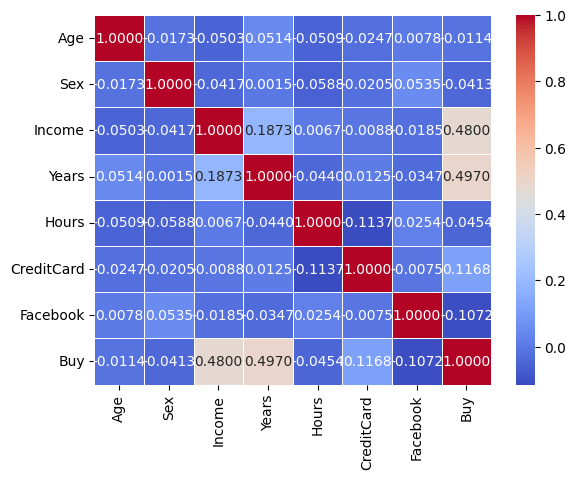

In [33]:
sns.heatmap(mCorr, cmap="coolwarm", linewidths=0.5, annot=True, fmt=".4f")

# Punto 2. Determinar la variable que mejor lleva a cabo el proceso de caracterización de la compra del juego.

### La variable con mayor correlación con la compra del juego "Buy" es "Years" 0.4970, que son los años de experiencia con la plataforma.   

Por lo que, mientras más años lleve una persona jugando juegos en línea, más probable es que haga compras dentro de la app del juego.


# Punto 3. Según las variables de entrada y de salida, determinar cuáles variables tienen una mayor correlación entre ellas.

### La correlación entre las variables de entrada y la variable de salida con más correlación son:   

- Years VS Buy -> Con una correlación de 0.4970.  
- Income VS Buy -> Con una correlación de 0.4800.
- Income VS Years -> Con una correlación de 0.1873.

# Continuación del desarrollo

In [71]:
XDArray = np.array(XD, dtype=float)
ydArray = np.array(yd, dtype=float)

array([[ 40.,   0., 139., ...,  25.,   1.,   1.],
       [ 26.,   0., 138., ...,   4.,   1.,   1.],
       [ 48.,   0., 138., ...,   8.,   1.,   1.],
       ...,
       [ 35.,   1.,  65., ...,  21.,   0.,   0.],
       [ 25.,   1.,  64., ...,   3.,   1.,   1.],
       [ 44.,   1.,  64., ...,  26.,   1.,   0.]])

In [35]:
from sklearn.neighbors import KNeighborsClassifier

In [36]:
knnModel = KNeighborsClassifier(n_neighbors=10)

In [38]:
knnModel.fit(XDArray, ydArray)

KNeighborsClassifier(n_neighbors=10)

In [39]:
ydPred = knnModel.predict(XDArray)

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [42]:
cm = confusion_matrix(yd, ydPred)
cm

array([[128,  61],
       [ 33, 178]])

# Punto 4. Determinar el comportamiento del modelo KNN en el pronóstico de los datos utilizados para la configuración del modelo en cuanto a exactitud, sensibilidad y especificidad

In [45]:
# METRICAS DE EVALUACION

# Valores de la matriz de confusión
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]

# METRICAS
# Exactitud (Acurracy)
exactitud=(VN+VP)/cm.sum()
print(f"La exactitud (accuracy) del modelo es de {exactitud:.2%}")

# Tasas de error
error = 1-exactitud
print(f"El error del modelo es de {error:.2%}")

# Precisión
presicion = VP/(VP+FP)
print(f"La precisión del modelo es de {presicion:.2%}")

# Sensibilidad
sensibilidad = VP/(VP+FN)
print(f"La sensibilidad del modelo es de {sensibilidad:.2%}")

# Especificidad
especificidad = VN/(VN+FP)
print(f"La especificidad del modelo es de {especificidad:.2%}")

La exactitud (accuracy) del modelo es de 76.50%
El error del modelo es de 23.50%
La precisión del modelo es de 74.48%
La sensibilidad del modelo es de 84.36%
La especificidad del modelo es de 67.72%


# Continuación del desarrollo

In [46]:
from sklearn.metrics import roc_auc_score

In [47]:
roc_auc_score(ydArray, ydPred)

0.7604252864916372

In [67]:
XDi = np.array([(21, 1, 128, 3, 22, 0, 1)])

# Punto 5. Determinar si una persona con las siguientes características va a alquilar una casa esta temporada utilizando el modelo KNN ['Age',    'Sex',    'Income',    'Years', 'Hours', 'CreditCard', 'Facebook']= [(21,    1,    128,    3,    22,    0,    1)] De acuerdo con el individuo anterior, llevar a cabo su ubicación en la gráfica del modelo KNN y del modelo KMeans teniendo en cuenta para ello las variables 'Income' vs 'Year

In [70]:
ydi = knnModel.predict(XDi)
print(f"La decisión de la persona frente comprar el juego es {ydi}, es decir, no lo compraría.")

La decisión frente comprar el juego es [0.], es decir, no lo compraría.


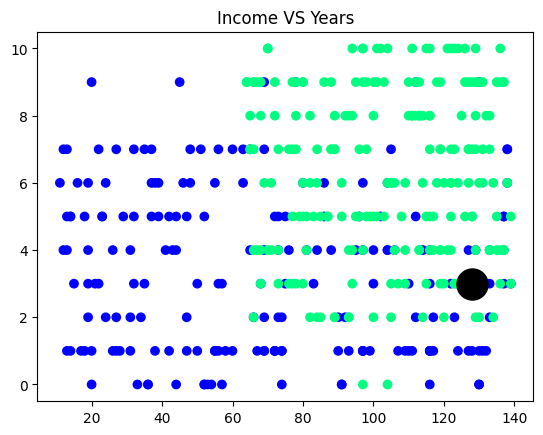

In [76]:
import matplotlib.pyplot as plt

plt.scatter(XDArray[:,2], XDArray[:,3], c=ydArray, cmap="winter")
plt.scatter(XDi[:,2], XDi[:,3], facecolor="black", s=500)
plt.title("Income VS Years")
plt.show()

# Continuación del desarrollo

In [126]:
from sklearn.cluster import KMeans

In [127]:
np.random.seed(42)
k=5

In [128]:
kMeansModel = KMeans(n_clusters=k, init="random", random_state=42)
kMeansModel

KMeans(init='random', n_clusters=5, random_state=42)

In [129]:
kMeansModel.fit(XD, yd)

KMeans(init='random', n_clusters=5, random_state=42)

In [130]:
AAA["cluster"] = labels

In [131]:
counts_2 = AAA.groupby("cluster").agg({"Buy":lambda x : (x==0).sum()})
counts_3 = AAA.groupby("cluster").agg({"Buy":lambda x : (x==1).sum()})

In [132]:
df = pd.DataFrame(np.column_stack((counts_2, counts_3)))
df

,0,1
0,22,49
1,67,0
2,30,67
3,18,47
4,52,48


# Punto 6. Determinar el número de individuos que va a comprar un juego a través de la app, de acuerdo con la estructura de cada uno de los clústeres.

### Según la estructura de los clusters:   
- El clúster 1 con índice 0 tiene 49 personas que van a comprar el juego a través de la app.
-  El clúster 2 con índice 1 tiene 0 personas que van a comprar el juego a través de la app.
-  El clúster 3 con índice 2 tiene 67 personas que van a comprar el juego a través de la app.
-  El clúster 4 con índice 3 tiene 47 personas que van a comprar el juego a través de la app.
-  El clúster 5 con índice 4 tiene 48 personas que van a comprar el juego a través de la app.   

En total, 211 individuos comprarán el juego según la estructura de todos los clústeres

# Punto 7. Indica cual es el clúster donde las personas en promedio son más jóvenes, donde en promedio hay más mujeres, donde en promedio tienen más años de juego y el clúster donde en promedio tienen más tarjetas de crédito.

In [139]:
AAA[['Age', 'Sex', 'Years', 'CreditCard', "cluster"]].groupby(['cluster']).agg(['mean'])

,Age,Sex,Years,CreditCard
,mean,mean,mean,mean
cluster,,,,
0,49.929577,0.380282,5.267606,0.535211
1,40.417910,0.477612,3.791045,0.522388
2,24.979381,0.443299,5.164948,0.536082
3,51.030769,0.461538,5.323077,0.476923
4,36.690000,0.540000,4.630000,0.570000


- El clúster en el que las personas en promedio con más jóvenes es en el clúster 3 con índice 2.  
- El clúster en el que hay más mujeres en promedio es es en el clúster 1 con índice 1.  
- El clúster que tiene más años de juego en promedio es en el clúster 2 con índice 1.  
- El clúster en el que hay personas con más tarjetas de crédito en promedio es en el clúster 5 con índice 4.